In [49]:
import re
import os
import glob
from pathlib import Path
import pandas as pd

In [50]:

results_df = pd.read_csv('results_var_selectedpos.csv')

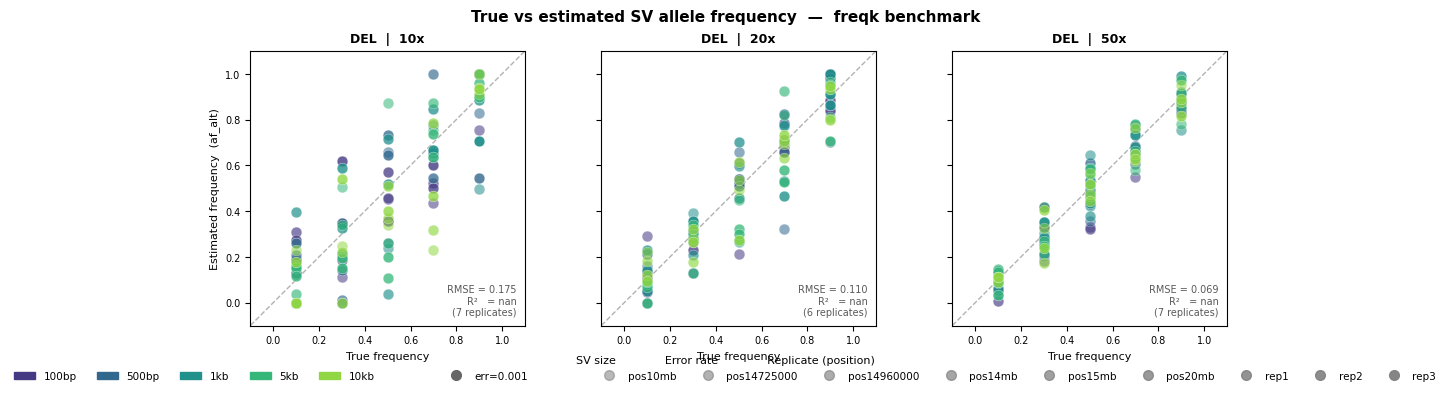

In [51]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from pathlib import Path

# ── Aesthetics ─────────────────────────────────────────────────────────────────
SIZE_ORDER  = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette     = sns.color_palette("viridis", len(SIZE_ORDER))
SIZE_COLORS = dict(zip(SIZE_ORDER, palette))

# Each error_rate gets a marker shape; positions (replicates) are individual dots
error_rates  = sorted(results_df["error_rate"].unique())
ERR_MARKERS  = dict(zip(error_rates, ["o", "s", "^", "D"]))

# Each replicate position gets an alpha level to make overlap visible
positions    = sorted(results_df["pos_label"].unique())
POS_ALPHA    = {p: a for p, a in zip(positions, np.linspace(0.55, 0.95, len(positions)))}

sv_types  = ["DEL"]
coverages = sorted(results_df["coverage"].unique())

# ── Layout: rows = sv_type, cols = coverage ────────────────────────────────────
nrows, ncols = len(sv_types), len(coverages)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6 * ncols, 3.6 * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
if nrows == 1: axes = [axes]
if ncols == 1: axes = [[ax] for ax in axes]

lo, hi = -0.1, 1.1

for i, svt in enumerate(sv_types):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        subset = results_df[(results_df["sv_type"] == svt) & (results_df["coverage"] == cov)]

        # Plot every replicate position as a separate dot
        for err in error_rates:
            for size in SIZE_ORDER:
                for pos in positions:
                    pts = subset[
                        (subset["error_rate"] == err) &
                        (subset["size"]       == size) &
                        (subset["pos_label"]  == pos)
                    ]
                    if pts.empty:
                        continue
                    ax.scatter(
                        pts["freq_nominal"], pts["af_alt"],
                        color      = SIZE_COLORS.get(size, "grey"),
                        marker     = ERR_MARKERS.get(err, "x"),
                        alpha      = POS_ALPHA[pos],
                        s          = 60,
                        edgecolors = "white",
                        linewidths = 0.3,
                        zorder     = 3,
                    )

        # Identity line
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--", alpha=0.3, zorder=1)

        # RMSE and R² over all replicates
        if not subset.empty:
            rmse  = np.sqrt(((subset["af_alt"] - subset["freq_nominal"]) ** 2).mean())
            r2    = np.corrcoef(subset["freq_nominal"], subset["af_alt"])[0, 1] ** 2
            n_rep = subset["pos_label"].nunique()
            ax.text(0.97, 0.03,
                    f"RMSE = {rmse:.3f}\nR²   = {r2:.3f}\n({n_rep} replicates)",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_title(f"{svt}  |  {cov}x", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Estimated frequency  (af_alt)", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── Legends ────────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
err_handles  = [
    mlines.Line2D([], [], color="0.4", marker=ERR_MARKERS[e], linestyle="None",
                  markersize=7, label=f"err={e}")
    for e in error_rates
]
pos_handles  = [
    mlines.Line2D([], [], color="0.5", marker="o", linestyle="None",
                  markersize=7, alpha=POS_ALPHA[p], label=p)
    for p in positions
]

fig.legend(
    handles=size_patches
            + [mpatches.Patch(visible=False)]
            + err_handles
            + [mpatches.Patch(visible=False)]
            + pos_handles,
    title="SV size              Error rate              Replicate (position)",
    loc="lower center",
    ncol=len(SIZE_ORDER) + 1 + len(err_handles) + 1 + len(pos_handles),
    fontsize=7.5, title_fontsize=8,
    bbox_to_anchor=(0.5, -0.07),
    frameon=False,
)

fig.suptitle("True vs estimated SV allele frequency  —  freqk benchmark",
             fontsize=11, fontweight="bold")

#Path("../plots/").mkdir(exist_ok=True)
#fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated_var.pdf", bbox_inches="tight")
#fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated_var.png", bbox_inches="tight", dpi=150)
plt.show()


In [52]:
results_df['pos_label'].value_counts()

pos_label
pos10mb        77
pos14725000    75
pos14960000    75
pos15mb        75
pos20mb        75
pos14mb         6
rep1            1
rep2            1
rep3            1
Name: count, dtype: int64

In [53]:
results_df.groupby('pos_label')['abs_error'].mean()

pos_label
pos10mb        0.106273
pos14725000         NaN
pos14960000    0.096032
pos14mb        0.110928
pos15mb        0.080110
pos20mb        0.084465
rep1           0.086895
rep2           0.062672
rep3           0.194668
Name: abs_error, dtype: float64

In [54]:

from collections import Counter
from Bio import SeqIO

FASTA        = "../data/reference/Chr1.fa"
K            = 31
REGISTRY_WIN = 10_000   # fixed window used by pipeline/registry

def _parse_pos(label: str) -> int:
    label = label.replace("pos", "")
    if label.endswith("mb"):
        return int(label[:-2]) * 1_000_000
    return int(label)

def build_repeat_set(ref_seq: str, k: int = K) -> frozenset:
    seen_once = set()
    repeated  = set()
    seq_clean = ref_seq.replace("N", "")
    for i in range(len(seq_clean) - k + 1):
        km = seq_clean[i : i + k]
        if km in seen_once:
            repeated.add(km)
        else:
            seen_once.add(km)
    del seen_once
    return frozenset(repeated)

def repeat_score(seq: str, repeat_set: frozenset, k: int = K) -> float:
    """Fraction of k-mers in seq that appear >=2x genome-wide."""
    seq   = seq.replace("N", "")
    total = len(seq) - k + 1
    if total <= 0:
        return float("nan")
    return sum(1 for i in range(total) if seq[i : i + k] in repeat_set) / total

def classify(rs: float) -> str:
    if rs < 0.10: return "low repeat"
    if rs < 0.50: return "moderate repeat"
    return "high repeat"

print("Loading reference ...", end=" ", flush=True)
ref_seq = str(next(SeqIO.parse(FASTA, "fasta")).seq).upper()
print(f"done  ({len(ref_seq):,} bp)")

print("Building genome-wide k-mer repeat set ... (may take ~30 s)", end=" ", flush=True)
genome_repeat_set = build_repeat_set(ref_seq)
print(f"done  ({len(genome_repeat_set):,} multi-copy k-mers)")

# Only process old-style fixed-position labels (pos*); skip rep* labels
unique_labels = [l for l in results_df["pos_label"].unique()
                 if not str(l).startswith("rep")]
results_df = results_df[results_df["pos_label"].isin(unique_labels)].copy()

# Registry-equivalent score: fixed 10 kb window [pos, pos+10kb] — matches pipeline
pos_meta = {}
print("\n  label            pos (Mb)  repeat_score  region_type")
print("  " + "-" * 55)
for lbl in sorted(unique_labels):
    pos = _parse_pos(lbl)
    rs  = repeat_score(ref_seq[pos : pos + REGISTRY_WIN], genome_repeat_set)
    rtype = classify(rs)
    pos_meta[lbl] = {"pos_bp": pos, "repeat_score": rs, "region_type": rtype}
    print(f"  {lbl:15s}  {pos/1e6:7.3f}    {rs:10.3f}  {rtype}")

results_df["pos_bp"]       = results_df["pos_label"].map(lambda l: pos_meta[l]["pos_bp"])
results_df["repeat_score"] = results_df["pos_label"].map(lambda l: pos_meta[l]["repeat_score"])
results_df["region_type"]  = results_df["pos_label"].map(lambda l: pos_meta[l]["region_type"])
results_df["detected"]     = results_df["af_alt"].notna()

print("\nDetection rate by region_type:")
print(results_df.groupby("region_type")["detected"].mean().round(3).to_string())


Loading reference ... done  (30,427,671 bp)
Building genome-wide k-mer repeat set ... (may take ~30 s) done  (587,396 multi-copy k-mers)

  label            pos (Mb)  repeat_score  region_type
  -------------------------------------------------------
  pos10mb           10.000         0.183  moderate repeat
  pos14725000       14.725         0.934  high repeat
  pos14960000       14.960         0.929  high repeat
  pos14mb           14.000         0.039  low repeat
  pos15mb           15.000         0.040  low repeat
  pos20mb           20.000         0.034  low repeat

Detection rate by region_type:
region_type
high repeat        0.5
low repeat         1.0
moderate repeat    1.0


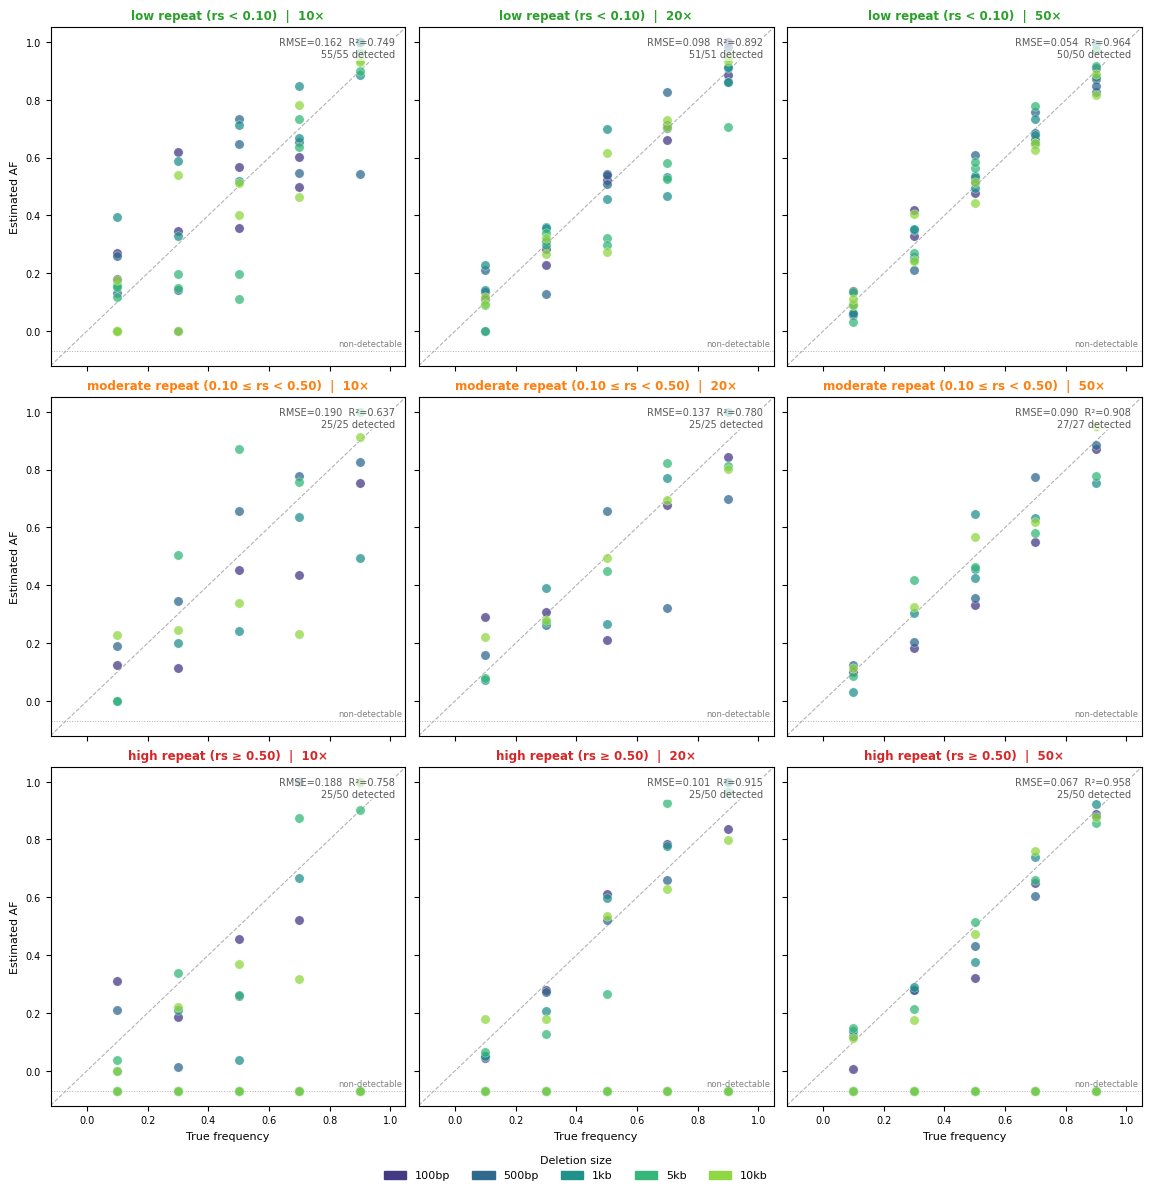

In [55]:

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from pathlib import Path

# ── Plot 2: True vs estimated AF, split by region type ───────────────────────
#
# Detected rows: scatter true vs estimated, coloured by deletion size
# Non-detected rows: circles at y = -0.07 ("non-detectable" band), same size colour
#
# Rows = region_type (low / moderate / high repeat)
# Cols = coverage

SIZE_ORDER   = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette      = sns.color_palette("viridis", len(SIZE_ORDER))
SIZE_COLORS  = dict(zip(SIZE_ORDER, palette))

REGION_ORDER  = ["low repeat", "moderate repeat", "high repeat"]
REGION_COLORS = {"low repeat": "#2ca02c", "moderate repeat": "#ff7f0e", "high repeat": "#d62728"}

# RS threshold labels shown in each panel title
REGION_RANGE = {
    "low repeat":      "rs < 0.10",
    "moderate repeat": "0.10 ≤ rs < 0.50",
    "high repeat":     "rs ≥ 0.50",
}

coverages = sorted(results_df["coverage"].unique())
nrows, ncols = len(REGION_ORDER), len(coverages)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.8 * nrows),
                         sharex=True, sharey=True, constrained_layout=True)

lo, hi = -0.12, 1.05
ND_Y   = -0.07

for i, rtype in enumerate(REGION_ORDER):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        sub = results_df[(results_df["region_type"] == rtype) &
                         (results_df["coverage"]    == cov)]

        det_sub  = sub[sub["detected"]]
        ndet_sub = sub[~sub["detected"]]

        # ── detected: filled circles ───────────────────────────────────────
        for size in SIZE_ORDER:
            pts = det_sub[det_sub["size"] == size]
            if pts.empty: continue
            ax.scatter(pts["freq_nominal"], pts["af_alt"],
                       color=SIZE_COLORS[size], marker="o", s=45, alpha=0.75,
                       edgecolors="white", linewidths=0.3, zorder=3)

        # ── non-detected: circles at bottom band, same size colour ─────────
        for size in SIZE_ORDER:
            pts = ndet_sub[ndet_sub["size"] == size]
            if pts.empty: continue
            ax.scatter(pts["freq_nominal"], [ND_Y] * len(pts),
                       color=SIZE_COLORS[size], marker="o", s=45, alpha=0.75,
                       edgecolors="white", linewidths=0.3, zorder=3)

        # ── reference lines ────────────────────────────────────────────────
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.3, zorder=1)
        ax.axhline(ND_Y, color="0.7", lw=0.7, ls=":", zorder=1)
        ax.text(hi - 0.01, ND_Y + 0.01, "non-detectable",
                ha="right", va="bottom", fontsize=6, color="0.5")

        # ── stats (detected only) ──────────────────────────────────────────
        n_tot = len(sub); n_det = len(det_sub)
        if n_det >= 2:
            rmse = np.sqrt(((det_sub["af_alt"] - det_sub["freq_nominal"]) ** 2).mean())
            r2   = np.corrcoef(det_sub["freq_nominal"], det_sub["af_alt"])[0, 1] ** 2
            ax.text(0.97, 0.97,
                    f"RMSE={rmse:.3f}  R²={r2:.3f}\n{n_det}/{n_tot} detected",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        color = REGION_COLORS[rtype]
        ax.set_title(f"{rtype} ({REGION_RANGE[rtype]})  |  {cov}×",
                     fontsize=8.5, fontweight="bold", color=color)
        if j == 0:
            ax.set_ylabel("Estimated AF", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── legend ─────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
fig.legend(handles=size_patches,
           title="Deletion size",
           loc="lower center", ncol=len(SIZE_ORDER),
           fontsize=8, title_fontsize=8,
           bbox_to_anchor=(0.5, -0.04), frameon=False)


#plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_est_by_region.pdf",
#            bbox_inches="tight")
#plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_est_by_region.png",
#            bbox_inches="tight", dpi=150)
plt.show()


In [62]:
results_df.to_csv('results_var_selectedpos_w_repeatscore.csv')

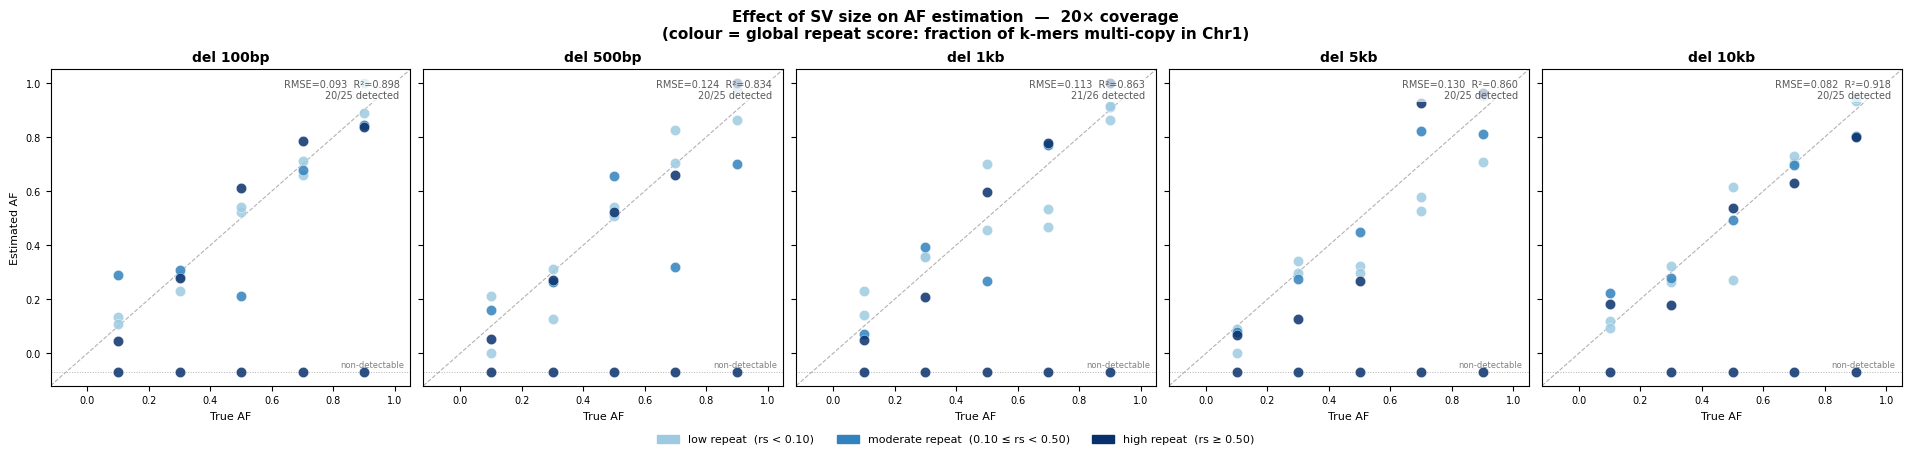

In [61]:

# ── Plot: Effect of SV size on AF estimation  (coverage = 20×) ───────────────
#
# One panel per SV size (100bp → 10kb)
# x = true AF (freq_nominal), y = estimated AF (af_alt)
# Colour = repeat level (sequential light→dark blue as global repeat increases)
# All points: filled circles
#   · Detected:     on the scatter field
#   · Non-detected: circles in the "non-detectable" band at y = -0.07
#
# Requires genome_repeat_set and ref_seq in scope from the enrichment cell above.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import SeqIO

TARGET_COV = 20

df = pd.read_csv("results_var_selectedpos.csv")
df = df[df["coverage"] == TARGET_COV].copy()
df["detected"] = df["af_alt"].notna()

def _parse_pos(label: str) -> int:
    label = label.replace("pos", "")
    return int(label[:-2]) * 1_000_000 if label.endswith("mb") else int(label)

REGISTRY_WIN = 10_000   # fixed window used by pipeline/registry

# Registry-equivalent repeat score: fixed 10 kb window [pos, pos+10kb]
pos_rs = {lbl: repeat_score(ref_seq[_parse_pos(lbl) : _parse_pos(lbl) + REGISTRY_WIN],
                            genome_repeat_set)
          for lbl in df["pos_label"].unique()}

def rtype(rs):
    if np.isnan(rs):  return "high repeat"
    if rs < 0.10:     return "low repeat"
    if rs < 0.50:     return "moderate repeat"
    return "high repeat"

df["repeat_score"] = df["pos_label"].map(pos_rs)
df["region_type"]  = df["repeat_score"].map(rtype)




# Sequential blue palette: light → dark as global repeat level increases
REGION_ORDER  = ["low repeat", "moderate repeat", "high repeat"]
REGION_COLORS = {"low repeat": "#9ecae1", "moderate repeat": "#3182bd", "high repeat": "#08306b"}

REGION_RANGE = {
    "low repeat":      "rs < 0.10",
    "moderate repeat": "0.10 ≤ rs < 0.50",
    "high repeat":     "rs ≥ 0.50",
}

SIZE_ORDER = ["100bp", "500bp", "1kb", "5kb", "10kb"]
ncols = len(SIZE_ORDER)
fig, axes = plt.subplots(1, ncols, figsize=(3.8 * ncols, 4.2),
                         sharex=True, sharey=True, constrained_layout=True)

lo, hi = -0.12, 1.05
ND_Y = -0.07

for ax, size in zip(axes, SIZE_ORDER):
    sub  = df[df["size"] == size]
    det  = sub[sub["detected"]]
    ndet = sub[~sub["detected"]]

    for rg in REGION_ORDER:
        c = REGION_COLORS[rg]
        pts = det[det["region_type"] == rg]
        if not pts.empty:
            ax.scatter(pts["freq_nominal"], pts["af_alt"],
                       color=c, marker="o", s=55, alpha=0.85,
                       edgecolors="white", linewidths=0.3, zorder=3)
        pts = ndet[ndet["region_type"] == rg]
        if not pts.empty:
            ax.scatter(pts["freq_nominal"], [ND_Y] * len(pts),
                       color=c, marker="o", s=55, alpha=0.85,
                       edgecolors="white", linewidths=0.3, zorder=3)

    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.3, zorder=1)
    ax.axhline(ND_Y, color="0.7", lw=0.7, ls=":", zorder=1)
    ax.text(hi - 0.02, ND_Y + 0.01, "non-detectable",
            ha="right", va="bottom", fontsize=6, color="0.5")

    if len(det) >= 2:
        rmse = np.sqrt(((det["af_alt"] - det["freq_nominal"]) ** 2).mean())
        r2   = np.corrcoef(det["freq_nominal"], det["af_alt"])[0, 1] ** 2
        n_det, n_tot = len(det), len(sub)
        ax.text(0.97, 0.97,
                f"RMSE={rmse:.3f}  R²={r2:.3f}\n{n_det}/{n_tot} detected",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7, color="0.35",
                bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f"del {size}", fontsize=10, fontweight="bold")
    ax.set_xlabel("True AF", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("Estimated AF", fontsize=8)

legend_handles = [
    mpatches.Patch(color=REGION_COLORS[rg],
                   label=f"{rg}  ({REGION_RANGE[rg]})")
    for rg in REGION_ORDER
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.07), frameon=False)

fig.suptitle(f"Effect of SV size on AF estimation  —  {TARGET_COV}× coverage\n"
             "(colour = global repeat score: fraction of k-mers multi-copy in Chr1)",
             fontsize=11, fontweight="bold")

#import os; os.makedirs("/Users/tatiana/Documents_new/visor_freqk/plots", exist_ok=True)
#plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/sv_size_effect_cov20.pdf",
#            bbox_inches="tight")
#plt.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/sv_size_effect_cov20.png",
#            bbox_inches="tight", dpi=150)
plt.show()
